## Import Libraries

In [2]:
import os
import cv2
import h5py
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from glob import glob
from scipy.io import loadmat
from skimage.draw import disk
import tensorflow as tf
from tensorflow.keras import layers, models

## Define path

In [3]:
train_img_dir = "Dataset/ShanghaiTech/part_A/train_data/images"
train_gt_dir = "Dataset/ShanghaiTech/part_A/train_data/ground-truth"
test_img_dir = "Dataset/ShanghaiTech/part_A/test_data/images"
test_gt_dir = "Dataset/ShanghaiTech/part_A/test_data/ground-truth"

density_map_dir = "Dataset/ShanghaiTech/density_maps"
os.makedirs(density_map_dir, exist_ok=True)


## Density map generator

In [4]:
def generate_density_map(image, points, sigma=4):
    h, w = image.shape[:2]
    density = np.zeros((h, w), dtype=np.float32)
    for point in points:
        x = min(int(point[0]), w - 1)
        y = min(int(point[1]), h - 1)
        rr, cc = disk((y, x), sigma, shape=density.shape)
        density[rr, cc] += 1
    return density


## Generate and Save Normalized Density Maps

In [5]:
train_imgs = sorted(glob(os.path.join(train_img_dir, "*.jpg")))

for img_path in tqdm(train_imgs):
    fname = os.path.basename(img_path).replace(".jpg", "")
    gt_path = os.path.join(train_gt_dir, f"GT_{fname}.mat")
    mat = loadmat(gt_path)
    points = mat["image_info"][0][0][0][0][0]

    image = cv2.imread(img_path)
    density = generate_density_map(image, points)

    np.save(os.path.join(density_map_dir, f"{fname}.npy"), density)


100%|████████████████████████████████████████████████████████████████████████████████| 300/300 [00:05<00:00, 54.17it/s]


## Data Generator

In [6]:
class CrowdDataset(tf.keras.utils.Sequence):
    def __init__(self, image_paths, density_paths, batch_size=4, input_size=(224, 224)):
        self.image_paths = image_paths
        self.density_paths = density_paths
        self.batch_size = batch_size
        self.input_size = input_size

    def __len__(self):
        return len(self.image_paths) // self.batch_size

    def __getitem__(self, idx):
        X = []
        Y = []
        for i in range(self.batch_size):
            index = idx * self.batch_size + i
            image = cv2.imread(self.image_paths[index])
            image = cv2.resize(image, self.input_size)
            image = image.astype(np.float32) / 255.0

            fname = os.path.basename(self.image_paths[index]).replace(".jpg", "")
            density = np.load(self.density_paths[index])
            density = cv2.resize(density, self.input_size)
            density = density.astype(np.float32)
            density *= (np.sum(density) / (np.sum(density) + 1e-6))  # Preserve total count

            X.append(image)
            Y.append(density[..., np.newaxis])
        return np.array(X), np.array(Y)


## Define MCNN model

In [7]:
def mcnn(input_shape=(224, 224, 3)):
    def column_block(filters, kernel_size):
        return models.Sequential([
            layers.Conv2D(filters, kernel_size, activation='relu', padding='same'),
            layers.Conv2D(filters, kernel_size, activation='relu', padding='same'),
            layers.MaxPooling2D()
        ])

    inputs = layers.Input(shape=input_shape)

    # Three columns with different receptive fields
    col1 = column_block(16, 9)(inputs)
    col2 = column_block(20, 7)(inputs)
    col3 = column_block(24, 5)(inputs)

    merged = layers.concatenate([col1, col2, col3])
    x = layers.Conv2D(1, 1, activation='linear', padding='same')(merged)

    # Add an upsampling layer to match the input size
    x = layers.UpSampling2D(size=(2, 2), interpolation='bilinear')(x)


    model = models.Model(inputs=inputs, outputs=x)
    return model

## Load Data

In [8]:
train_images = sorted(glob(os.path.join(train_img_dir, "*.jpg")))
train_density = sorted(glob(os.path.join(density_map_dir, "*.npy")))

train_gen = CrowdDataset(train_images, train_density, batch_size=4)


## Compile and Train

In [9]:
model = mcnn()
model.compile(optimizer='adam', loss='mse')
model.fit(train_gen, epochs=30)

C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 0.0947
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0500
Epoch 3/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0514
Epoch 4/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0505
Epoch 5/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0487
Epoch 6/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0474
Epoch 7/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0553
Epoch 8/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 0.0483
Epoch 9/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 0.0531
Epoch 10/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 0.0486
Epoch 11/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 0.0442
Epoch 12/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 0.0480
Epoch 13/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0448
Epoch 14/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 0.0468
Epoch 15/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0481
Epoc

## Evaluate MAE and RMSE

In [10]:
test_images = sorted(glob(os.path.join(test_img_dir, "*.jpg")))
test_gt = sorted(glob(os.path.join(test_gt_dir, "*.mat")))

mae = 0
mse = 0
for i in tqdm(range(len(test_images))):
    image = cv2.imread(test_images[i])
    image_resized = cv2.resize(image, (224, 224)).astype(np.float32) / 255.0

    mat = loadmat(test_gt[i])
    points = mat["image_info"][0][0][0][0][0]
    gt_count = len(points)

    pred_density = model.predict(np.expand_dims(image_resized, axis=0))[0, ..., 0]
    pred_count = np.sum(pred_density)

    mae += abs(gt_count - pred_count)
    mse += (gt_count - pred_count) ** 2

mae /= len(test_images)
mse = np.sqrt(mse / len(test_images))
print(f"MAE: {mae:.2f}, RMSE: {mse:.2f}")


  0%|                                                                                          | 0/182 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


  1%|▉                                                                                 | 2/182 [00:00<00:11, 15.24it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


  3%|██▎                                                                               | 5/182 [00:00<00:09, 19.42it/s]

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


 98%|██████████████████████████████████████████████████████████████████████████████▋ | 179/182 [00:07<00:00, 23.35it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


100%|████████████████████████████████████████████████████████████████████████████████| 182/182 [00:07<00:00, 22.86it/s]

MAE: 2884.99, RMSE: 3086.29


## Visualization

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


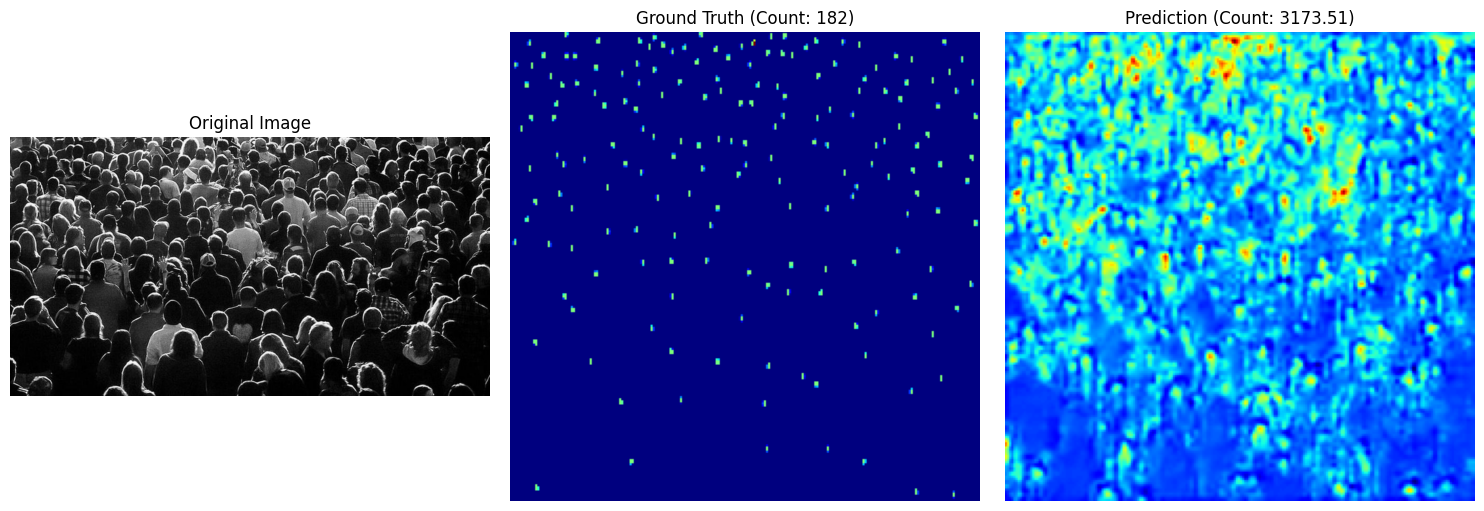

In [12]:
image_path = test_images[10]

mat_path = test_gt[10]
input_size=(224, 224)

image = cv2.imread(image_path)
image_resized = cv2.resize(image, input_size).astype(np.float32) / 255.0

mat = loadmat(mat_path)
points = mat["image_info"][0][0][0][0][0]
gt_density = generate_density_map(image, points)
gt_resized = cv2.resize(gt_density, input_size)

pred_density = model.predict(np.expand_dims(image_resized, axis=0))[0, ..., 0]
pred_count = np.sum(pred_density)
gt_count = len(points)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gt_resized, cmap='jet')
plt.title(f"Ground Truth (Count: {gt_count})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred_density, cmap='jet')
plt.title(f"Prediction (Count: {pred_count:.2f})")
plt.axis("off")

plt.tight_layout()
plt.show()
